<h1 style = "color: purple; text-align: center;font-family: Poppins; font-weight: 800;">Autonomous Model Reliability Engine (AMRE)</h1>

**Autonomous Model Reliability Engine (AMRE)
A production-grade self-healing ML system that continuously monitors data quality, detects feature and concept drift, diagnoses root causes using explainability methods, and automatically triggers model retraining or recalibration based on a policy-driven decision engine.**

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">1. Create a synthetic data</h2>

In [2]:
np.random.seed(42)

In [3]:
n = 5000

age = np.random.randint(19,60,n).round()
base_income = 8000
age_effect = -10 * (age - 45)**2 + 55000
raw_income = (base_income + age_effect + np.random.lognormal(9, 0.5, n))
income = (raw_income - raw_income.mean()) / raw_income.std()
income = (income * 20000 + 60000).round(2)
savings_rate = np.random.uniform(0.05, 0.3, n)
debt_ratio = np.random.uniform(0.1, 0.6, n)
noise = np.random.normal(0,0.03,n)
age_effect = -10 * (age - 40)**2 + 500
age_effect = (age_effect - age_effect.mean()) / age_effect.std()
purchase_power = (
    (income * (1 - savings_rate - debt_ratio))
    + (age_effect * 5000)
    + noise *4000).round(2)

In [4]:
data = {
    "age":age,
    "income":income,
    "savings_rate":savings_rate.round(2),
    "debt_ratio":debt_ratio.round(2),
    "purchase_power":purchase_power}

In [5]:
df = pd.DataFrame(data)
df

,age,income,savings_rate,debt_ratio,purchase_power
0,57,52651.67,0.07,0.42,21029.01
1,47,57833.38,0.22,0.43,23525.62
2,33,91580.17,0.22,0.52,27732.16
3,26,42537.86,0.22,0.39,14752.88
4,39,50845.70,0.29,0.33,24869.56
...,...,...,...,...,...
4995,37,58160.52,0.21,0.32,32361.67
4996,23,44873.35,0.28,0.41,8222.87
4997,41,59597.96,0.25,0.14,42214.66
4998,48,84507.79,0.10,0.57,30994.45


In [6]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
scaler = MinMaxScaler(feature_range=(1, 100))
purchasing_power = scaler.fit_transform(df[["purchase_power"]])
df["purchasing_power"] = pd.DataFrame(purchasing_power.round(2), columns=["purchasing_power"])
df

,age,income,savings_rate,debt_ratio,purchase_power,purchasing_power
0,57,52651.67,0.07,0.42,21029.01,22.28
1,47,57833.38,0.22,0.43,23525.62,24.03
2,33,91580.17,0.22,0.52,27732.16,26.97
3,26,42537.86,0.22,0.39,14752.88,17.89
4,39,50845.70,0.29,0.33,24869.56,24.96
...,...,...,...,...,...,...
4995,37,58160.52,0.21,0.32,32361.67,30.20
4996,23,44873.35,0.28,0.41,8222.87,13.33
4997,41,59597.96,0.25,0.14,42214.66,37.09
4998,48,84507.79,0.10,0.57,30994.45,29.25


In [8]:
df.to_csv("purchase_power.csv")

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">2. Exploratory Analysis</h2>

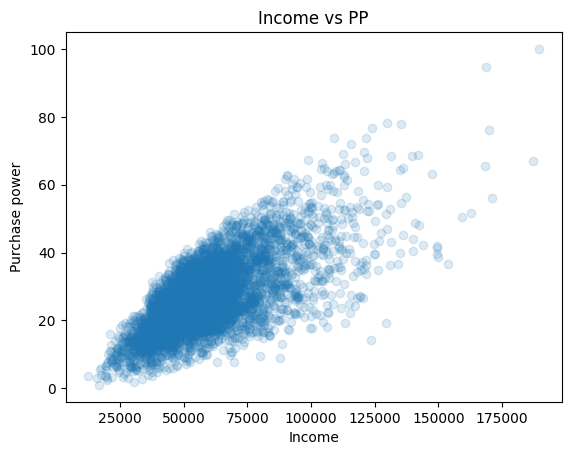

In [9]:
plt.scatter(df["income"], df["purchasing_power"], alpha=0.15)
plt.xlabel("Income")
plt.ylabel("Purchase power")
plt.title("Income vs PP")
plt.show()

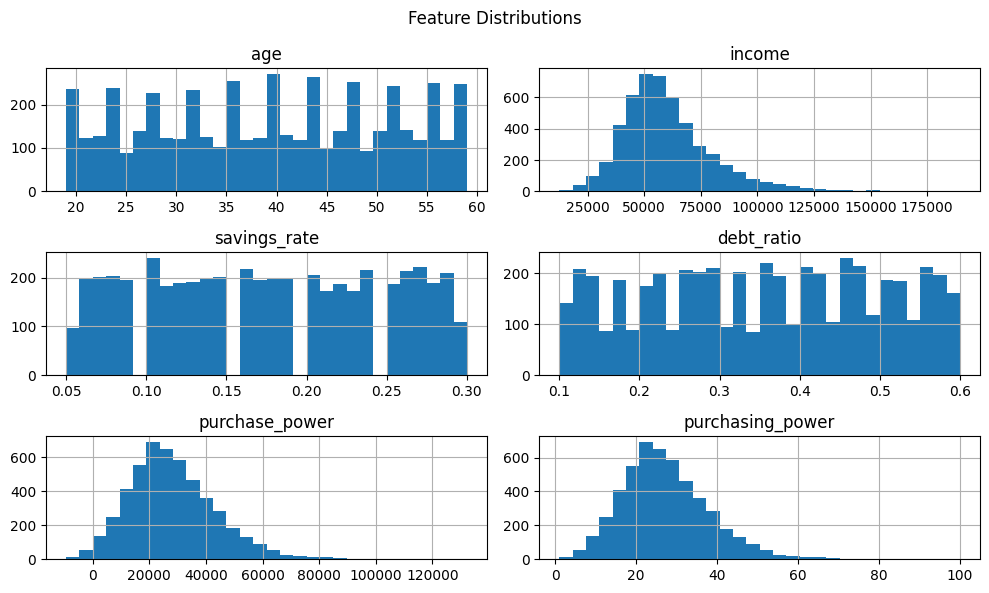

In [10]:
df.hist(figsize=(10,6), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

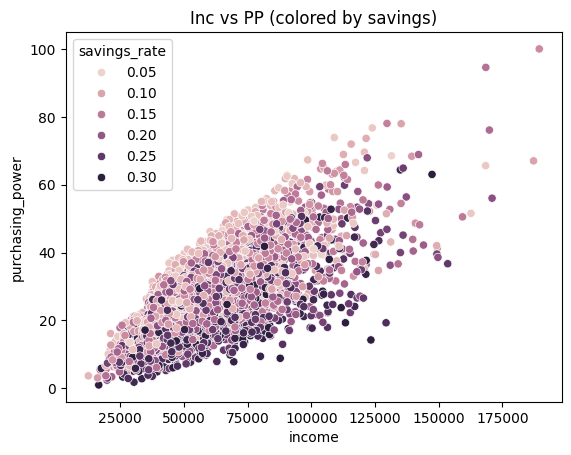

In [11]:
sns.scatterplot(data=df, x="income", y="purchasing_power", hue="savings_rate")
plt.title("Inc vs PP (colored by savings)")
plt.show()

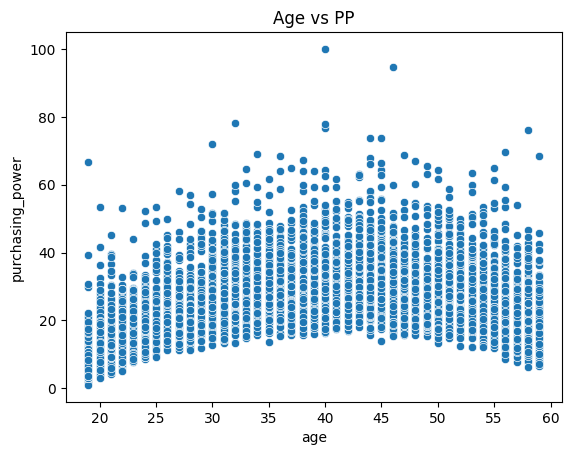

In [12]:
sns.scatterplot(data=df, x="age", y="purchasing_power")
plt.title("Age vs PP")
plt.show()

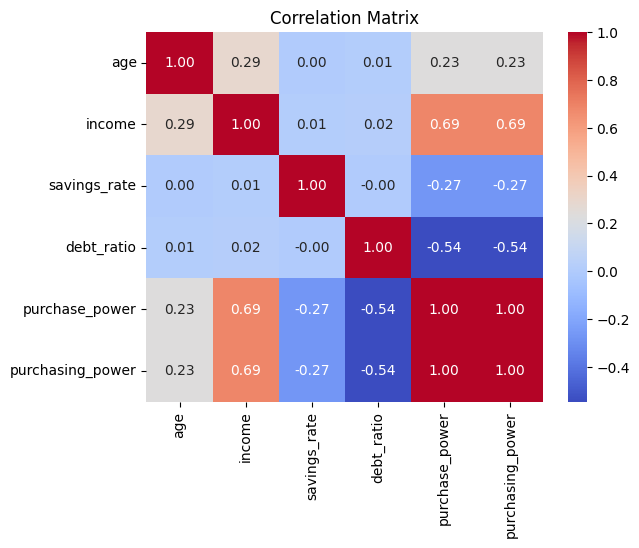

In [13]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">3. Baseline Model Training</h2>

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [15]:
X = df.drop(["purchase_power", "purchasing_power"],axis=1)
y = df.purchasing_power

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">4. Baseline Model Performance</h2>

In [19]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,max_error

In [20]:
mean_squared_error(y_test, y_pred) 

18.584808808304974

In [21]:
baseline_mse = mean_absolute_error(y_test, y_pred) 
baseline_mse

3.4770415114822777

In [22]:
baseline_r2 = r2_score(y_test, y_pred) 
baseline_r2

0.8296317945756015

In [23]:
max_error(y_test, y_pred) 

19.66728541345201

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">4. Data Drift</h2>

In [24]:
income += np.random.normal(60000,12000,n)
age += np.random.randint(15,25,n)
savings_rate += np.random.normal(0.25,0.05,n)
debt_ratio += np.random.normal(0.3,0.03,n)
purchase_power = (
    (income * (1 - savings_rate - debt_ratio))
    + (age_effect * 5000)
    + noise *4000).round(2)

In [25]:
data_d = {
    "age":age,
    "income":income,
    "savings_rate":savings_rate.round(2),
    "debt_ratio":debt_ratio.round(2),
    "purchase_power":purchase_power}

In [26]:
df_d = pd.DataFrame(data_d)
df_d

,age,income,savings_rate,debt_ratio,purchase_power
0,76,98552.095170,0.28,0.74,-7747.13
1,68,126435.699777,0.47,0.70,-17858.90
2,52,149927.354492,0.47,0.81,-38733.09
3,44,105712.367200,0.40,0.73,-16287.61
4,59,100459.566112,0.41,0.65,-155.95
...,...,...,...,...,...
4995,61,116933.540220,0.36,0.66,2748.91
4996,42,92255.815906,0.42,0.71,-18239.94
4997,58,118919.623875,0.40,0.44,25334.64
4998,65,135060.228939,0.24,0.87,-12143.93


In [27]:
scaler = MinMaxScaler(feature_range=(1, 100))
purchasing_power = scaler.fit_transform(df_d[["purchase_power"]])
df_d["purchasing_power"] = pd.DataFrame(purchasing_power.round(2), columns=["purchasing_power"])
df_d

,age,income,savings_rate,debt_ratio,purchase_power,purchasing_power
0,76,98552.095170,0.28,0.74,-7747.13,51.07
1,68,126435.699777,0.47,0.70,-17858.90,44.92
2,52,149927.354492,0.47,0.81,-38733.09,32.23
3,44,105712.367200,0.40,0.73,-16287.61,45.88
4,59,100459.566112,0.41,0.65,-155.95,55.68
...,...,...,...,...,...,...
4995,61,116933.540220,0.36,0.66,2748.91,57.45
4996,42,92255.815906,0.42,0.71,-18239.94,44.69
4997,58,118919.623875,0.40,0.44,25334.64,71.18
4998,65,135060.228939,0.24,0.87,-12143.93,48.40


In [28]:
X_d = df_d.drop(["purchase_power", "purchasing_power"],axis=1)
y_d = df_d.purchasing_power

In [29]:
yd_pred = model.predict(X_d)

In [30]:
drift_mse = mean_absolute_error(y_d, yd_pred) 
drift_mse

23.405648064590252

In [31]:
drift_r2 = r2_score(y_d, yd_pred) 
drift_r2

-2.728689212403118

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">5. Drift Detection</h2>

In [32]:
def compare_kde(df, drifted_df, col):
    plt.figure()
    
    sns.kdeplot(df[col], label="Original", fill=True)
    sns.kdeplot(drifted_df[col], label="Drifted", fill=True)
    
    plt.title(f"KDE Comparison: {col}")
    plt.legend()
    plt.show()

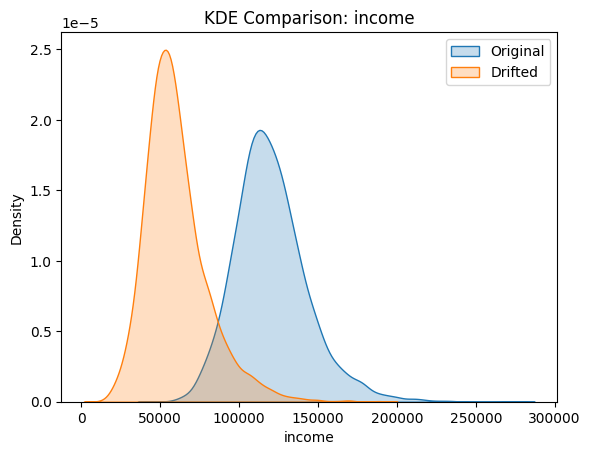

In [33]:
compare_kde(df_d, df, "income")

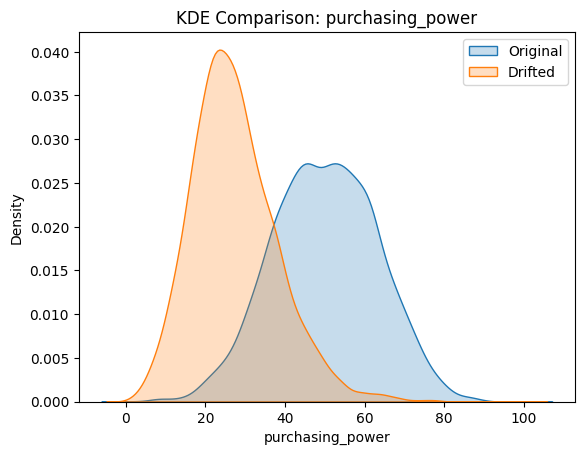

In [34]:
compare_kde(df_d, df, "purchasing_power")

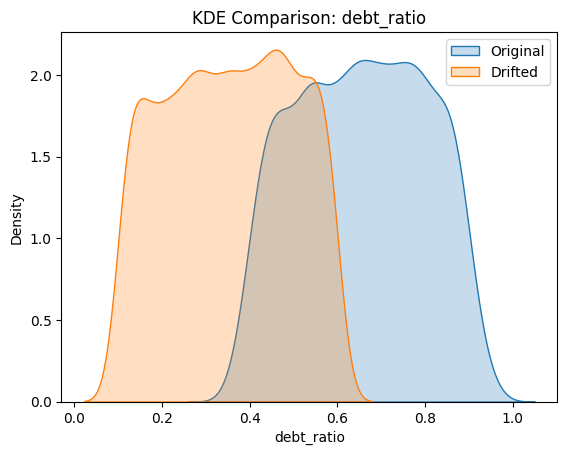

In [35]:
compare_kde(df_d, df, "debt_ratio")

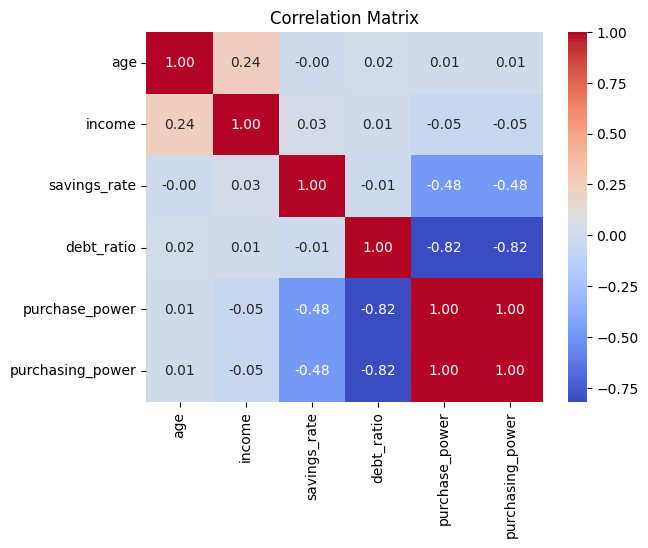

In [36]:
sns.heatmap(df_d.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix_d.png")
plt.show()

In [37]:
def drift_score(old, new):
    scores = []
    for col in old.columns:
        old_mean = old[col].mean()
        new_mean = new[col].mean()
        old_std = old[col].std()
        score = abs(new_mean - old_mean) / old_std
        scores.append(score)
    return np.mean(scores)
    
drift_score = drift_score(df, df_d)
drift_score

np.float64(2.449760021681924)

In [38]:
def data_quality_score(df):
    missing = df.isnull().mean().mean()
    outliers = ((np.abs(df - df.mean()) > 3*df.std()).mean().mean())

    score = 100 - (missing*50 + outliers*50)
    return score

quality_score = data_quality_score(df_d)
quality_score

np.float64(99.87166666666667)

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">6. Decision Engine</h2>

In [39]:
def decision_engine(drift_score, quality_score, mse_drop):

    if quality_score < 60:
        return "BLOCK_RETRAIN"

    elif drift_score > 1.5 and mse_drop > 2:
        return "RETRAIN_FULL_MODEL"

    elif drift_score > 1:
        return "RECALIBRATE"

    else:
        return "MONITOR"

In [40]:
action = decision_engine(
    drift_score=drift_score,
    quality_score=quality_score,
    mse_drop=(drift_mse - baseline_mse)
)
action

'RETRAIN_FULL_MODEL'

In [41]:
if action == "RETRAIN_FULL_MODEL":
    new_model = LinearRegression()
    new_model.fit(X_d, y_d)
    new_preds = new_model.predict(X_d)
    new_mse = mean_squared_error(y_d, new_preds)
    new_mse

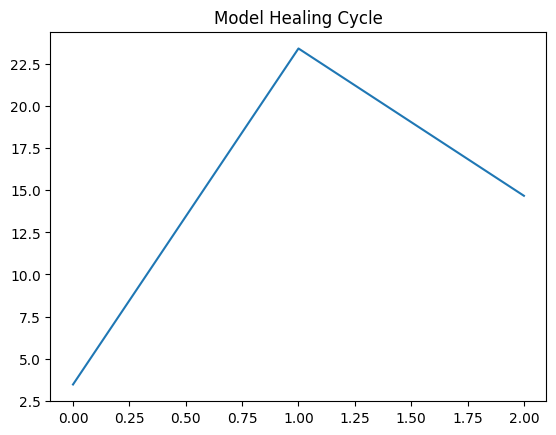

In [42]:
plt.plot([baseline_mse, drift_mse, new_mse])
plt.title("Model Healing Cycle")
plt.savefig("model_healing_cycle.png")
plt.show()